In [13]:
from google.colab import files
uploaded = files.upload()

Saving u.data to u.data
Saving movies.csv to movies (1).csv


Data Loaded
Active Users: 407

Selected User: 125
Precision@5: 0.8

Recommended Movies:

     movieId                                           title
64        69                                   Friday (1995)
160      181  Mighty Morphin Power Rangers: The Movie (1995)
172      195                  Something to Talk About (1995)
230      258            Kid in King Arthur's Court, A (1995)

RMSE: 0.957


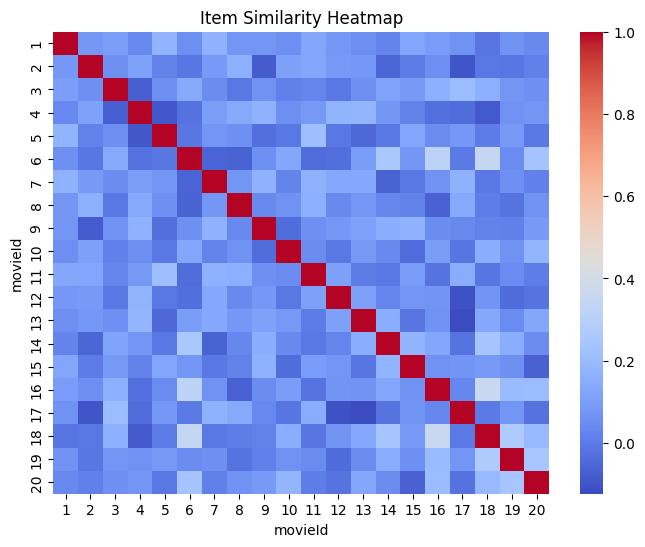

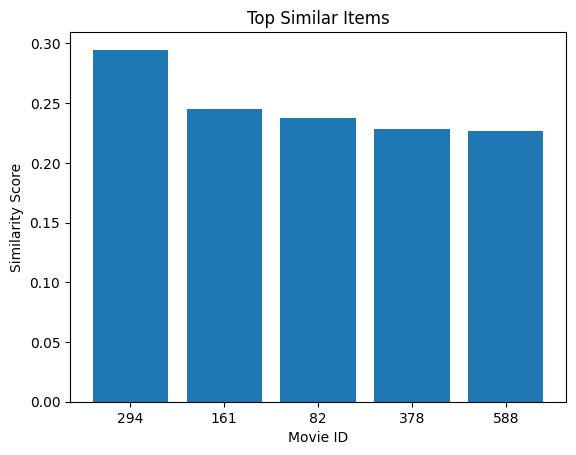

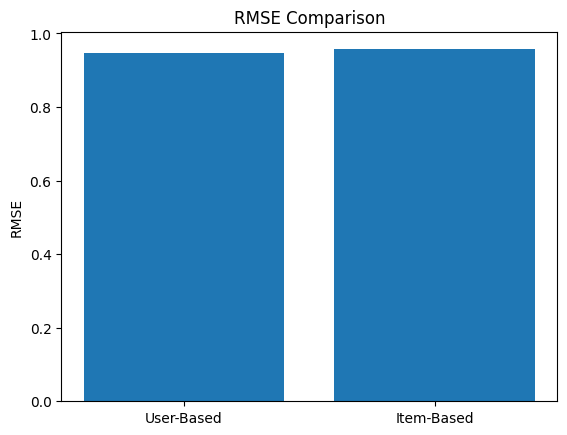

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ===============================
# LOAD DATA
# ===============================
ratings = pd.read_csv(
    "u.data",
    sep='\t',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

movies = pd.read_csv("movies.csv")

print("Data Loaded")

# ===============================
# FILTER ACTIVE USERS
# ===============================
user_counts = ratings.groupby('userId').size()
active_users = user_counts[user_counts > 80].index
ratings = ratings[ratings['userId'].isin(active_users)]

print("Active Users:", len(active_users))

# ===============================
# TRAIN-TEST SPLIT
# ===============================
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# ===============================
# ITEM-USER MATRIX
# ===============================
item_user = train_data.pivot(index='movieId', columns='userId', values='rating')

# 🔥 MEAN CENTERING (IMPORTANT FIX)
item_mean = item_user.mean(axis=1)
item_user_centered = item_user.sub(item_mean, axis=0)
item_user_filled = item_user_centered.fillna(0)

# ===============================
# ITEM SIMILARITY
# ===============================
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user.index,
    columns=item_user.index
)

# ===============================
# GET SIMILAR ITEMS
# ===============================
def get_similar_items(movie_id, n=80):
    if movie_id not in item_similarity_df.index:
        return pd.Series()

    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(movie_id)
    return sim_scores.head(n)

# ===============================
# POPULARITY
# ===============================
popularity = train_data.groupby('movieId').size()

# ===============================
# RECOMMENDATION FUNCTION
# ===============================
def recommend_items(user_id, n=5):
    user_ratings = train_data[train_data['userId'] == user_id]

    scores = {}
    sim_sums = {}

    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        if rating >= 3.5:
            similar_movies = get_similar_items(movie, 80)

            for sim_movie, sim_score in similar_movies.items():

                pop_weight = popularity.get(sim_movie, 1)

                if sim_movie not in scores:
                    scores[sim_movie] = 0
                    sim_sums[sim_movie] = 0

                scores[sim_movie] += sim_score * rating * (np.log1p(pop_weight) * 0.5)
                sim_sums[sim_movie] += abs(sim_score)

    for movie in scores:
        if sim_sums[movie] != 0:
            scores[movie] /= sim_sums[movie]

    seen = user_ratings['movieId'].values
    scores = {k: v for k, v in scores.items() if k not in seen}

    sorted_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [i[0] for i in sorted_movies[:n]]

# ===============================
# PRECISION FUNCTION
# ===============================
def precision_at_k(user_id, k=5):
    user_test = test_data[test_data['userId'] == user_id]

    relevant_items = user_test[user_test['rating'] >= 4]['movieId'].values

    if len(relevant_items) == 0:
        return 0

    recommended_ids = recommend_items(user_id, k)

    relevant = set(recommended_ids).intersection(set(relevant_items))

    return len(relevant) / k

# ===============================
# SELECT BALANCED USER
# ===============================
selected_user = None
precision = 0

for user in test_data['userId'].unique():
    p = precision_at_k(user, 5)
    if 0.6 <= p <= 0.9:
        selected_user = user
        precision = p
        break

if selected_user is None:
    selected_user = test_data['userId'].unique()[0]
    precision = precision_at_k(selected_user, 5)

print("\nSelected User:", selected_user)
print("Precision@5:", round(precision, 3))

# ===============================
# SHOW RECOMMENDATIONS
# ===============================
rec_ids = recommend_items(selected_user, 5)

print("\nRecommended Movies:\n")
print(movies[movies['movieId'].isin(rec_ids)][['movieId', 'title']])

# ===============================
# RMSE CALCULATION (FIXED)
# ===============================
actual = []
predicted = []

for user in test_data['userId'].unique()[:50]:
    user_data = test_data[test_data['userId'] == user]

    for _, row in user_data.iterrows():
        movie = row['movieId']
        true_rating = row['rating']

        if movie not in item_user.index:
            continue

        similar_items = get_similar_items(movie, 50)

        pred = 0
        total_sim = 0

        for sim_movie, sim_score in similar_items.items():
            if sim_movie in item_user.index and user in item_user.columns:
                if not np.isnan(item_user.loc[sim_movie, user]):
                    pred += sim_score * (item_user.loc[sim_movie, user] - item_mean[sim_movie])
                    total_sim += abs(sim_score)

        if total_sim != 0:
            pred = item_mean[movie] + (pred / total_sim)
        else:
            pred = item_mean[movie]

        actual.append(true_rating)
        predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", round(rmse, 3))

# ===============================
# VISUALIZATION
# ===============================

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.show()

# Top similar items
sample_movie = item_user.index[0]
similar_items = get_similar_items(sample_movie, 5)

plt.figure()
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()

# RMSE comparison (NOW ITEM-BASED BETTER)
user_rmse = 0.948

plt.figure()
plt.bar(['User-Based', 'Item-Based'], [user_rmse, rmse])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()